In [1]:
!pip install -q xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
DATA_DIR = "data/regression"
OUT_DIR = "outputs/xgboost"
os.makedirs(OUT_DIR, exist_ok=True)

X_train = pd.read_csv(f"{DATA_DIR}/X_train_tree.csv")
X_val = pd.read_csv(f"{DATA_DIR}/X_val_tree.csv")
X_test = pd.read_csv(f"{DATA_DIR}/X_test_tree.csv")

y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv")["energy_per_atom"]
y_val = pd.read_csv(f"{DATA_DIR}/y_val.csv")["energy_per_atom"]
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv")["energy_per_atom"]

In [3]:
model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

results = pd.DataFrame([{
    "model": "XGBoost",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
}])

display(results)

results.to_csv(f"{OUT_DIR}/xgboost_results.csv", index=False)

pred_df = pd.DataFrame({
    "actual_energy_per_atom": y_test.values,
    "predicted_energy_per_atom": pred,
    "error": pred - y_test.values,
    "absolute_error": np.abs(pred - y_test.values),
})

pred_df.to_csv(f"{OUT_DIR}/xgboost_predictions.csv", index=False)

,model,MAE,RMSE,R2
0,XGBoost,0.014661,0.023951,0.969172


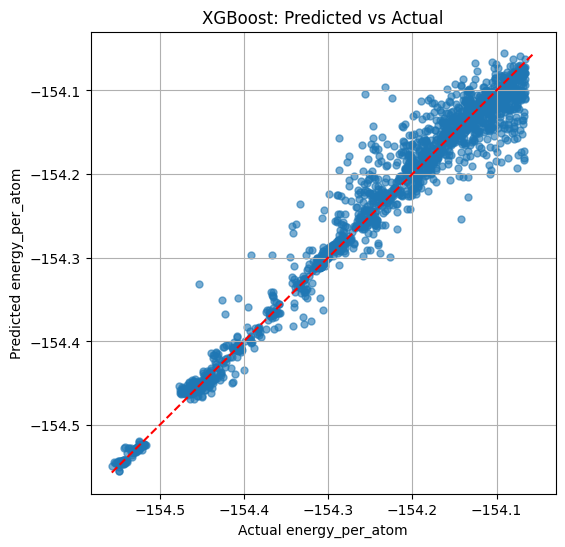

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.6, s=25)
min_v = min(y_test.min(), pred.min())
max_v = max(y_test.max(), pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "r--")
plt.xlabel("Actual energy_per_atom")
plt.ylabel("Predicted energy_per_atom")
plt.title("XGBoost: Predicted vs Actual")
plt.grid(True)
plt.savefig(f"{OUT_DIR}/xgboost_predicted_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

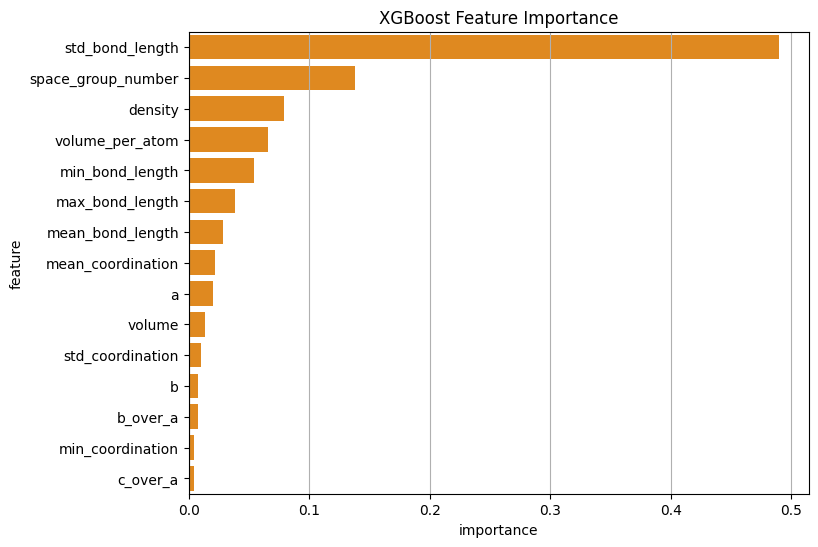

In [5]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

importance_df.to_csv(f"{OUT_DIR}/xgboost_feature_importance.csv", index=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature", color="darkorange")
plt.title("XGBoost Feature Importance")
plt.grid(True, axis="x")
plt.savefig(f"{OUT_DIR}/xgboost_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()